In [1]:
# 0. Import
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, log_loss
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
# 1. Adatok betöltése
df = pd.DataFrame()
seasons = ['2425', '2324', '2223', '2122', '2021']
leagues = ['E0', 'D1', 'SP1', 'I1', 'F1']


for season in seasons:
    for league in leagues:
        try:
            df_league = pd.read_csv(f'https://www.football-data.co.uk/mmz4281/{season}/{league}.csv')
            df_league['Season'] = season
            df = pd.concat([df, df_league], ignore_index=True)
        except:
            print(f"Could not load data for {season}/{league}")

print(f"Total matches loaded: {len(df)}")

Total matches loaded: 8982


In [3]:
# 2. Feature engineering
def create_features(df):
    # Data cleaning
    df = df.copy()
    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
    df = df.dropna(subset=['Date'])
    df = df.sort_values('Date')
    
    # Standardize column names - különböző ligák különböző oszlopneveket használnak
    if 'HomeTeam' not in df.columns and 'Home' in df.columns:
        df.rename(columns={'Home': 'HomeTeam', 'Away': 'AwayTeam'}, inplace=True)
    if 'FTHG' not in df.columns and 'HG' in df.columns:
        df.rename(columns={'HG': 'FTHG', 'AG': 'FTAG'}, inplace=True)
    if 'FTR' not in df.columns and 'Res' in df.columns:
        df.rename(columns={'Res': 'FTR'}, inplace=True)
    
    # Check if required columns exist
    required_cols = ['HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'Date']
    for col in required_cols:
        if col not in df.columns:
            print(f"Warning: Column {col} not found in dataframe")
            return df
    
    # Target variable
    df['Target'] = df['FTR'].map({'H': 0, 'D': 1, 'A': 2})
    
    # Implied probabilities from available odds
    df['Home_Implied_Prob'] = 1 / df['AvgH']
    df['Draw_Implied_Prob'] = 1 / df['AvgD']
    df['Away_Implied_Prob'] = 1 / df['AvgA']
    
    df['Home_Value'] = df['Home_Implied_Prob'] - 0.05
    df['Away_Value'] = df['Away_Implied_Prob'] - 0.05

    return df

df = create_features(df)
print("Basic features created")

# Create rolling statistics for each team - JAVÍTOTT
def create_team_features(df):
    all_matches = []
    
    # Get all unique team names
    home_teams = df['HomeTeam'].dropna().unique()
    away_teams = df['AwayTeam'].dropna().unique()
    teams = set(home_teams).union(set(away_teams))
    
    for team in teams:
        if pd.isna(team):
            continue
            
        try:
            # Get all matches for the team
            home_matches = df[df['HomeTeam'] == team].copy()
            away_matches = df[df['AwayTeam'] == team].copy()
            
            if len(home_matches) == 0 and len(away_matches) == 0:
                continue
                
            home_matches['Team_Type'] = 'Home'
            home_matches['Goals_For'] = home_matches['FTHG']
            home_matches['Goals_Against'] = home_matches['FTAG']
            home_matches['Points'] = home_matches['FTR'].map({'H': 3, 'D': 1, 'A': 0})
            
            away_matches['Team_Type'] = 'Away'
            away_matches['Goals_For'] = away_matches['FTAG']
            away_matches['Goals_Against'] = away_matches['FTHG']
            away_matches['Points'] = away_matches['FTR'].map({'H': 0, 'D': 1, 'A': 3})
            
            team_matches = pd.concat([home_matches, away_matches]).sort_values('Date')
            
            # Rolling statistics (last 5 matches)
            for window in [5]:
                team_matches[f'Points_Last_{window}'] = team_matches['Points'].rolling(window=window, min_periods=1).mean()
                team_matches[f'Goals_For_Last_{window}'] = team_matches['Goals_For'].rolling(window=window, min_periods=1).mean()
                team_matches[f'Goals_Against_Last_{window}'] = team_matches['Goals_Against'].rolling(window=window, min_periods=1).mean()
                team_matches[f'Form_Last_{window}'] = team_matches['Points'].rolling(window=window, min_periods=1).sum()
            
            all_matches.append(team_matches)
        except Exception as e:
            print(f"Error processing team {team}: {e}")
            continue
    
    if all_matches:
        team_stats = pd.concat(all_matches)
        return team_stats
    else:
        return pd.DataFrame()

# Create team features
team_stats = create_team_features(df)

if not team_stats.empty:
    # For home team features
    home_features = team_stats[team_stats['Team_Type'] == 'Home'][['Date', 'HomeTeam', 'Points_Last_5', 'Goals_For_Last_5', 
                                                                  'Goals_Against_Last_5', 'Form_Last_5']].copy()
    home_features = home_features.rename(columns={'HomeTeam': 'Team'})
    home_features.columns = ['Date', 'Team', 'Home_Points_Last_5', 'Home_Goals_For_Last_5',
                           'Home_Goals_Against_Last_5', 'Home_Form_Last_5']

    # For away team features
    away_features = team_stats[team_stats['Team_Type'] == 'Away'][['Date', 'AwayTeam', 'Points_Last_5', 'Goals_For_Last_5', 
                                                                  'Goals_Against_Last_5', 'Form_Last_5']].copy()
    away_features = away_features.rename(columns={'AwayTeam': 'Team'})
    away_features.columns = ['Date', 'Team', 'Away_Points_Last_5', 'Away_Goals_For_Last_5',
                           'Away_Goals_Against_Last_5', 'Away_Form_Last_5']

    # Merge with main dataframe
    df = df.merge(home_features, left_on=['Date', 'HomeTeam'], right_on=['Date', 'Team'], how='left')
    df = df.merge(away_features, left_on=['Date', 'AwayTeam'], right_on=['Date', 'Team'], how='left')
    
    # Drop the extra Team columns
    df = df.drop(columns=['Team_x', 'Team_y'], errors='ignore')
else:
    print("Warning: Could not create team features")

# Additional features
df['Home_Advantage'] = 1

# Calculate days since last match for each team
df = df.sort_values(['HomeTeam', 'Date'])
df['Days_Since_Last_Home_Match'] = df.groupby('HomeTeam')['Date'].diff().dt.days.fillna(30)

df = df.sort_values(['AwayTeam', 'Date'])
df['Days_Since_Last_Away_Match'] = df.groupby('AwayTeam')['Date'].diff().dt.days.fillna(30)

# Fill missing values
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(0)

print("Advanced features created")
print(f"Dataframe shape: {df.shape}")
print(f"Available columns: {list(df.columns)}")

Basic features created
Advanced features created
Dataframe shape: (8982, 150)
Available columns: ['Div', 'Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG', 'HTR', 'Referee', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR', 'B365H', 'B365D', 'B365A', 'BWH', 'BWD', 'BWA', 'BFH', 'BFD', 'BFA', 'PSH', 'PSD', 'PSA', 'WHH', 'WHD', 'WHA', '1XBH', '1XBD', '1XBA', 'MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA', 'BFEH', 'BFED', 'BFEA', 'B365>2.5', 'B365<2.5', 'P>2.5', 'P<2.5', 'Max>2.5', 'Max<2.5', 'Avg>2.5', 'Avg<2.5', 'BFE>2.5', 'BFE<2.5', 'AHh', 'B365AHH', 'B365AHA', 'PAHH', 'PAHA', 'MaxAHH', 'MaxAHA', 'AvgAHH', 'AvgAHA', 'BFEAHH', 'BFEAHA', 'B365CH', 'B365CD', 'B365CA', 'BWCH', 'BWCD', 'BWCA', 'BFCH', 'BFCD', 'BFCA', 'PSCH', 'PSCD', 'PSCA', 'WHCH', 'WHCD', 'WHCA', '1XBCH', '1XBCD', '1XBCA', 'MaxCH', 'MaxCD', 'MaxCA', 'AvgCH', 'AvgCD', 'AvgCA', 'BFECH', 'BFECD', 'BFECA', 'B365C>2.5', 'B365C<2.5', 'PC>2.5', 'PC<2.5', 'MaxC>2.5', 'MaxC<2.5', 

Using features: ['Home_Implied_Prob', 'Draw_Implied_Prob', 'Away_Implied_Prob', 'Home_Points_Last_5', 'Home_Goals_For_Last_5', 'Home_Goals_Against_Last_5', 'Away_Points_Last_5', 'Away_Goals_For_Last_5', 'Away_Goals_Against_Last_5', 'Home_Advantage', 'Days_Since_Last_Home_Match', 'Days_Since_Last_Away_Match']
Original data: 8982 matches
After cleaning: 8624 matches
Train matches: 7187, Test matches: 1437
TimeSeriesSplit with 5 folds
Training RandomForest with TimeSeriesSplit...
RandomForest CV Accuracy: 0.639 (+/- 0.017)
RandomForest feature importance:
                 feature  importance
3     Home_Points_Last_5    0.299637
6     Away_Points_Last_5    0.269886
2      Away_Implied_Prob    0.090640
7  Away_Goals_For_Last_5    0.069386
0      Home_Implied_Prob    0.067233
RandomForest trained successfully
Training GradientBoosting with TimeSeriesSplit...
GradientBoosting CV Accuracy: 0.655 (+/- 0.032)
GradientBoosting feature importance:
                     feature  importance
3        

c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Adam\AppData\Local\Programs\Python\Pytho

LogisticRegression CV Accuracy: 0.649 (+/- 0.032)

CROSS-VALIDATION RESULTS SUMMARY
RandomForest         | Mean: 0.639 | Std: 0.009
GradientBoosting     | Mean: 0.655 | Std: 0.016
LogisticRegression   | Mean: 0.649 | Std: 0.016
RandomForest predictions made - Accuracy: 0.651
GradientBoosting predictions made - Accuracy: 0.673
LogisticRegression predictions made - Accuracy: 0.674


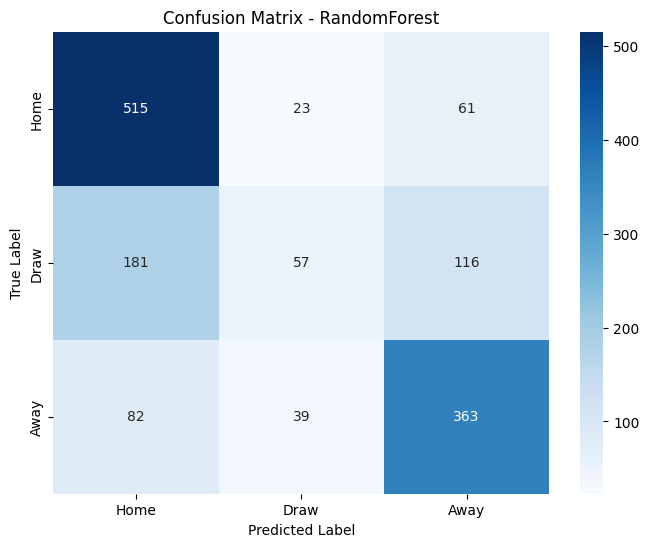

Classification Report - RandomForest:
              precision    recall  f1-score   support

        Home       0.66      0.86      0.75       599
        Draw       0.48      0.16      0.24       354
        Away       0.67      0.75      0.71       484

    accuracy                           0.65      1437
   macro avg       0.60      0.59      0.57      1437
weighted avg       0.62      0.65      0.61      1437

RandomForest - Weighted Precision: 0.620, Recall: 0.651, F1: 0.610


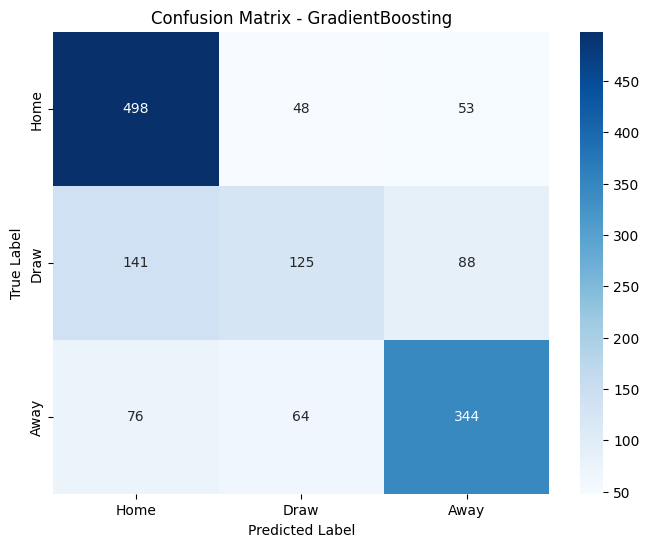

Classification Report - GradientBoosting:
              precision    recall  f1-score   support

        Home       0.70      0.83      0.76       599
        Draw       0.53      0.35      0.42       354
        Away       0.71      0.71      0.71       484

    accuracy                           0.67      1437
   macro avg       0.64      0.63      0.63      1437
weighted avg       0.66      0.67      0.66      1437

GradientBoosting - Weighted Precision: 0.659, Recall: 0.673, F1: 0.659


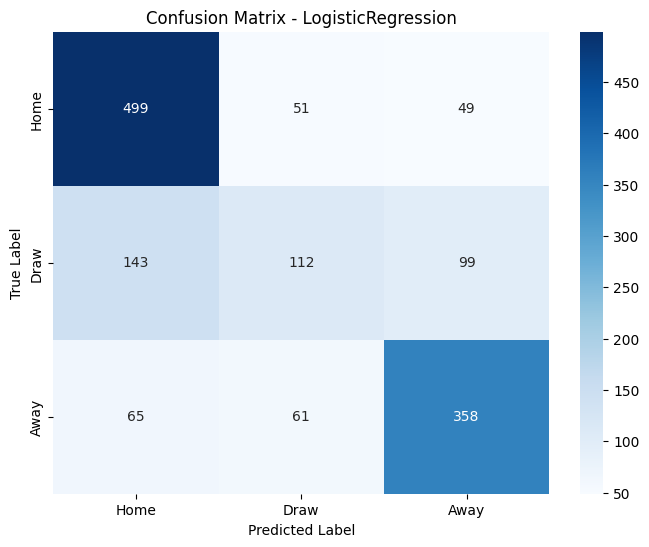

Classification Report - LogisticRegression:
              precision    recall  f1-score   support

        Home       0.71      0.83      0.76       599
        Draw       0.50      0.32      0.39       354
        Away       0.71      0.74      0.72       484

    accuracy                           0.67      1437
   macro avg       0.64      0.63      0.62      1437
weighted avg       0.66      0.67      0.66      1437

LogisticRegression - Weighted Precision: 0.656, Recall: 0.674, F1: 0.658


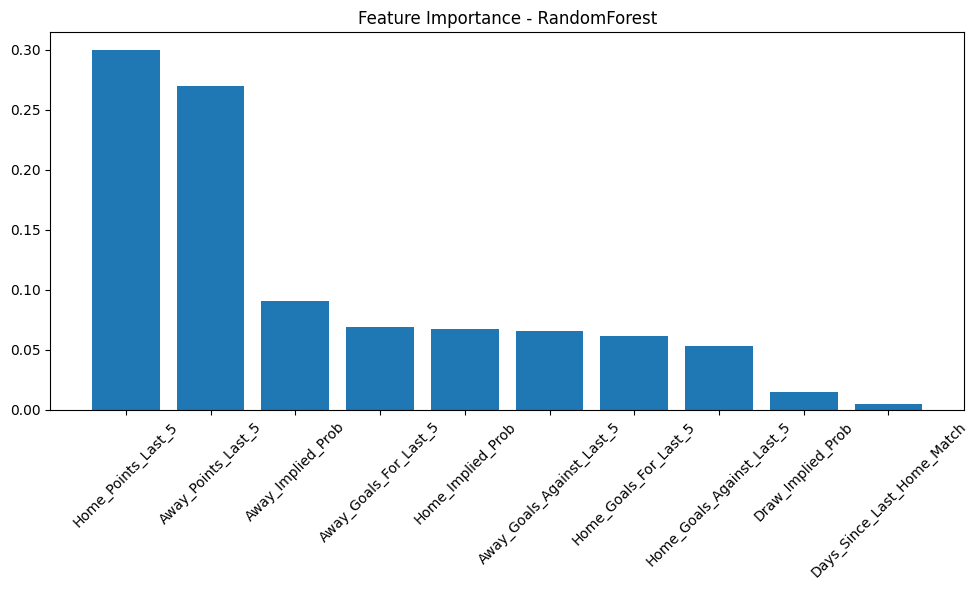

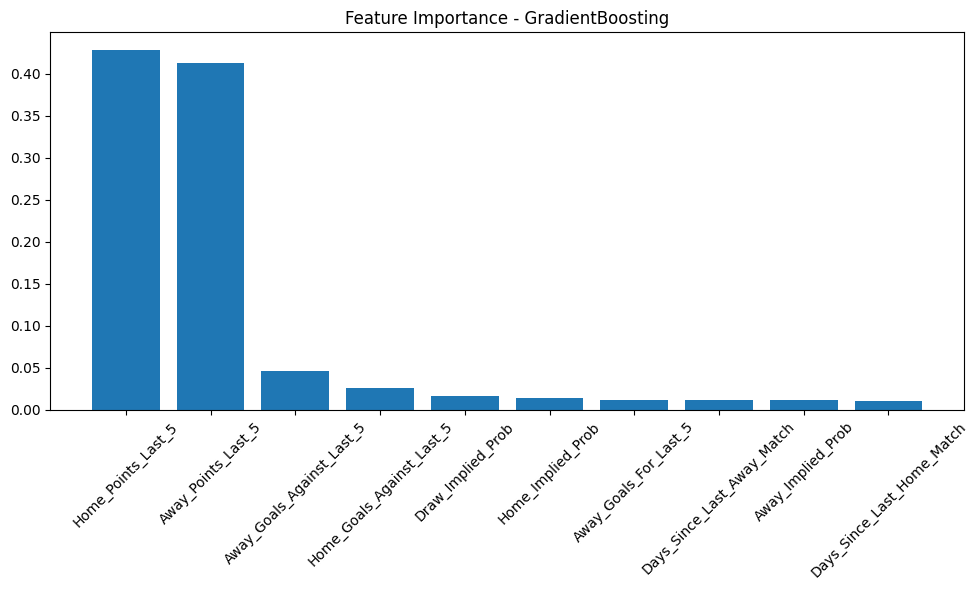

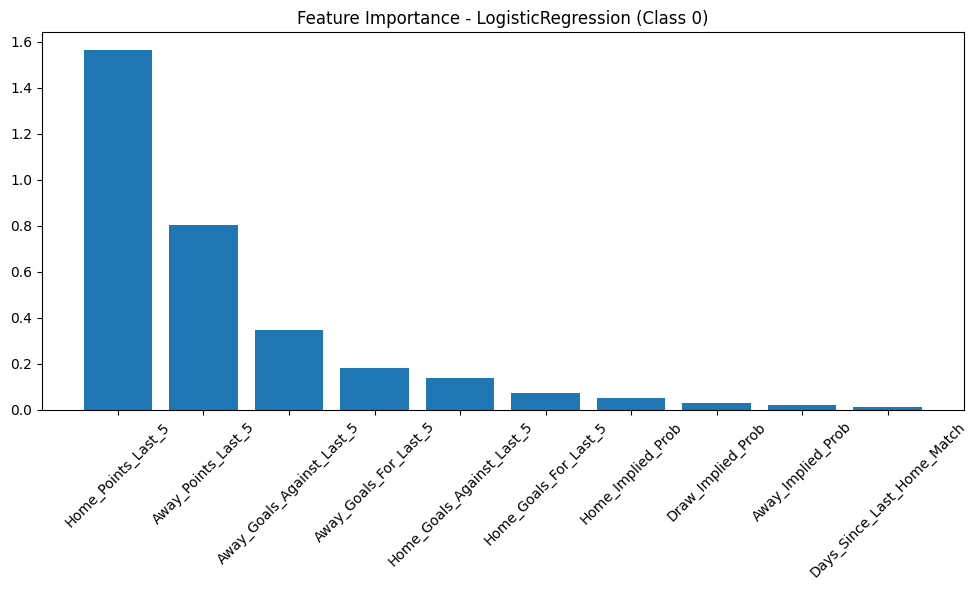

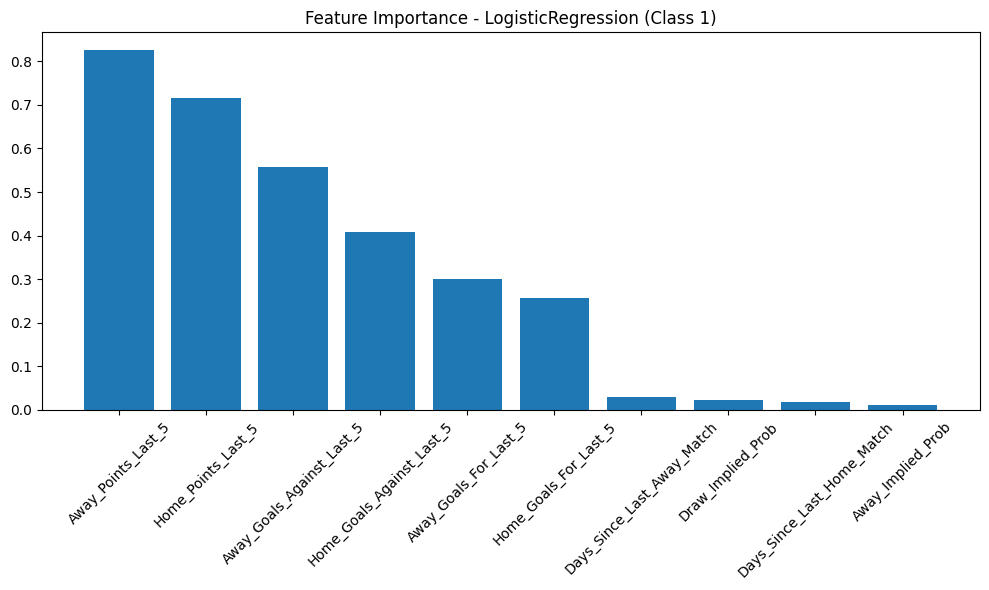

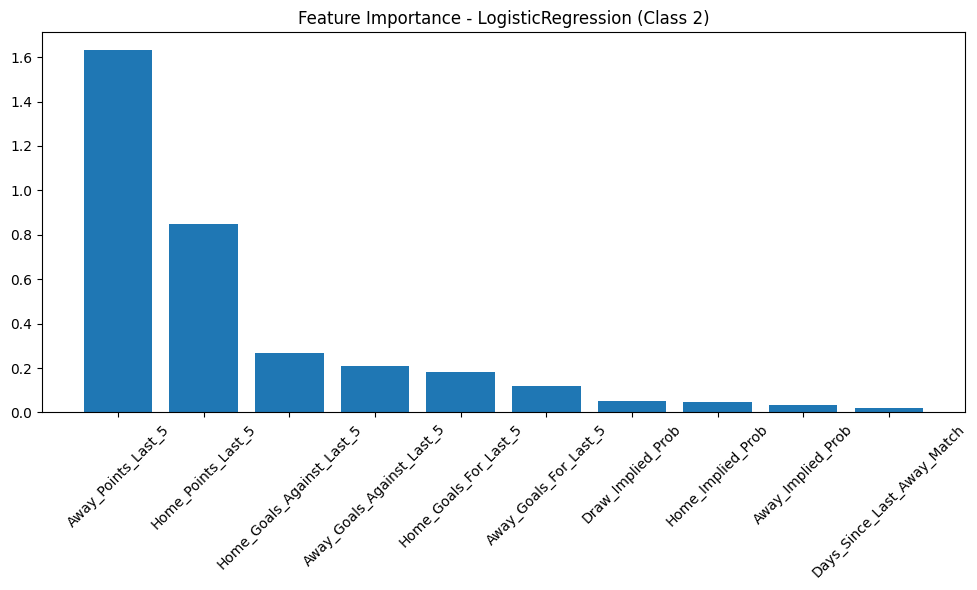

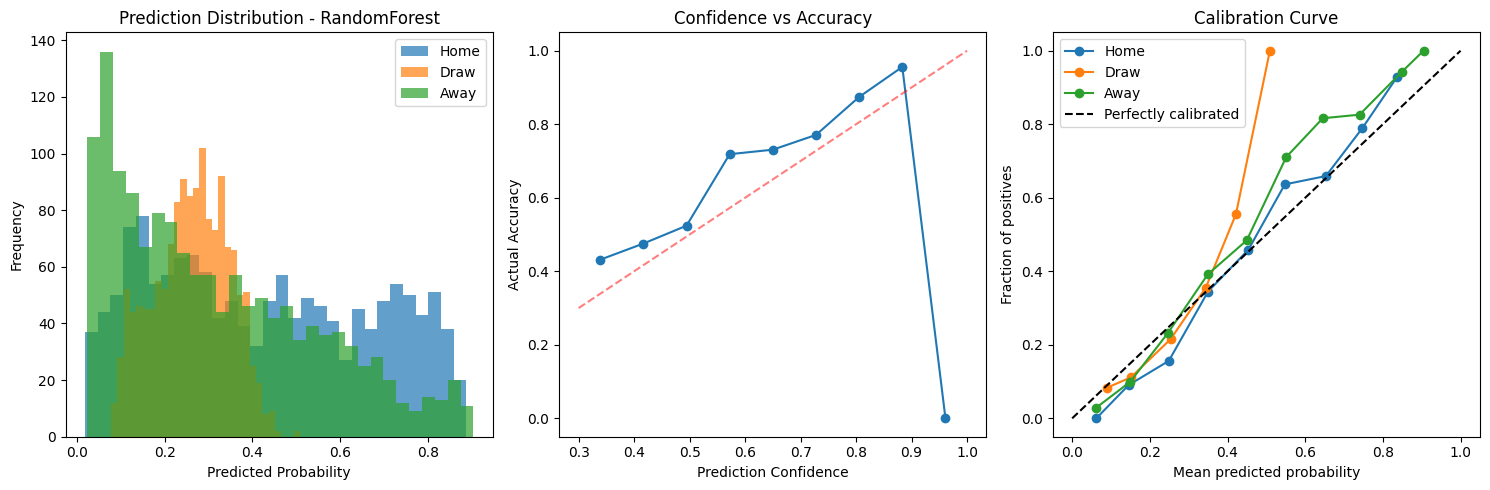

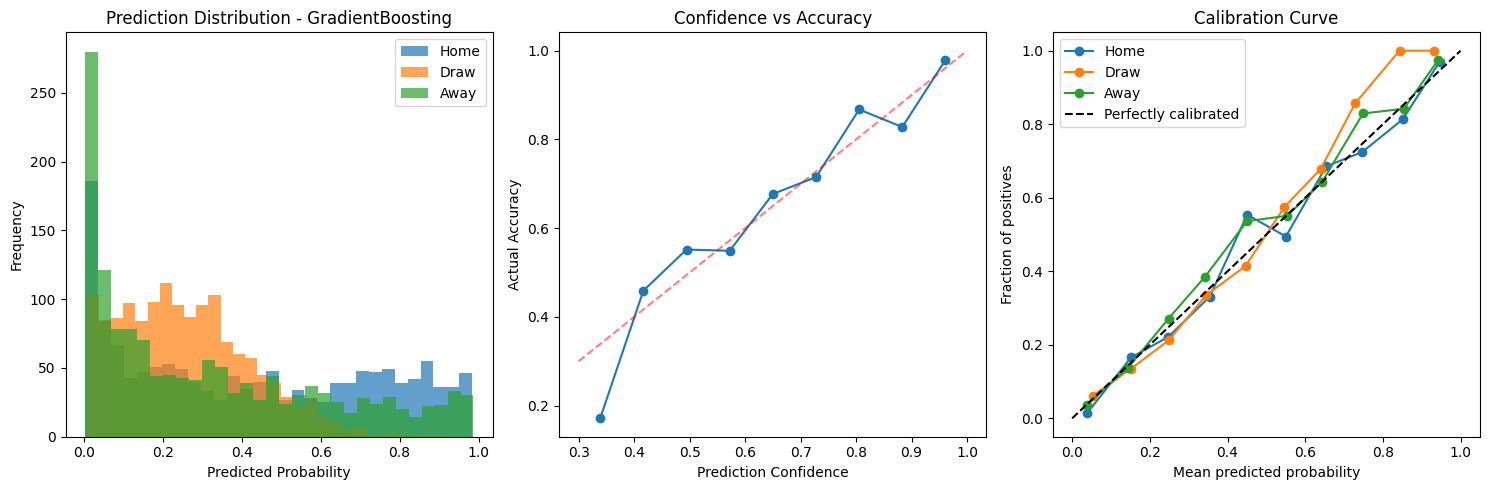

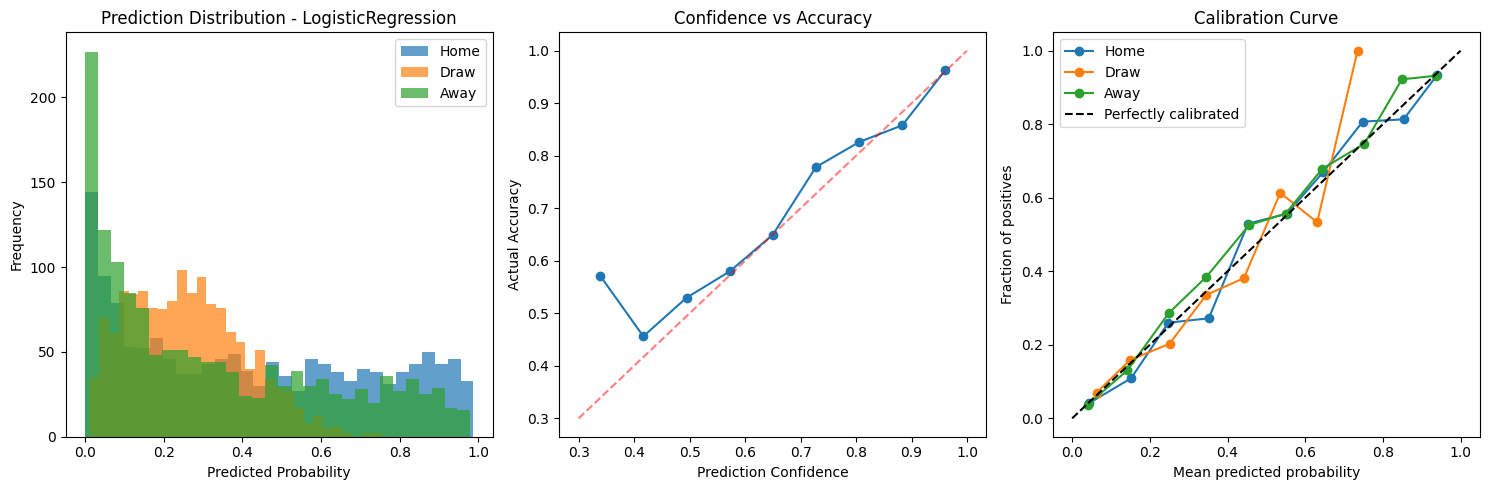

SHAP package not installed. Install with: pip install shap
Error Analysis - RandomForest:
Error rate by Home_Implied_Prob:
Home_Implied_Prob_bin
(-1.357, -0.44]    0.680556
(-0.44, 0.0366]    0.602778
(0.0366, 0.597]    0.632432
(0.597, 1.663]     0.688761
Name: Correct, dtype: float64

Error rate by Away_Implied_Prob:
Away_Implied_Prob_bin
(-1.1239999999999999, -0.482]    0.690608
(-0.482, -0.0324]                0.624650
(-0.0324, 0.518]                 0.612188
(0.518, 2.298]                   0.675070
Name: Correct, dtype: float64

Error rate by Home_Points_Last_5:
Home_Points_Last_5_bin
(-1.4009999999999998, -0.6]    0.711735
(-0.6, 0.0]                    0.544662
(0.0, 0.4]                     0.605809
(0.4, 1.6]                     0.753623
Name: Correct, dtype: float64

Most common error patterns:
Actual
1    297
2    121
0     84
Name: count, dtype: int64
Predicted as:
Predicted
0    263
2    177
1     62
Name: count, dtype: int64
Error Analysis - GradientBoosting:
Error rate

C:\Users\Adam\AppData\Local\Temp\ipykernel_20088\3624320520.py:367: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  error_rate = errors_df.groupby(f'{feature}_bin')['Correct'].mean()
C:\Users\Adam\AppData\Local\Temp\ipykernel_20088\3624320520.py:367: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  error_rate = errors_df.groupby(f'{feature}_bin')['Correct'].mean()
C:\Users\Adam\AppData\Local\Temp\ipykernel_20088\3624320520.py:367: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to a

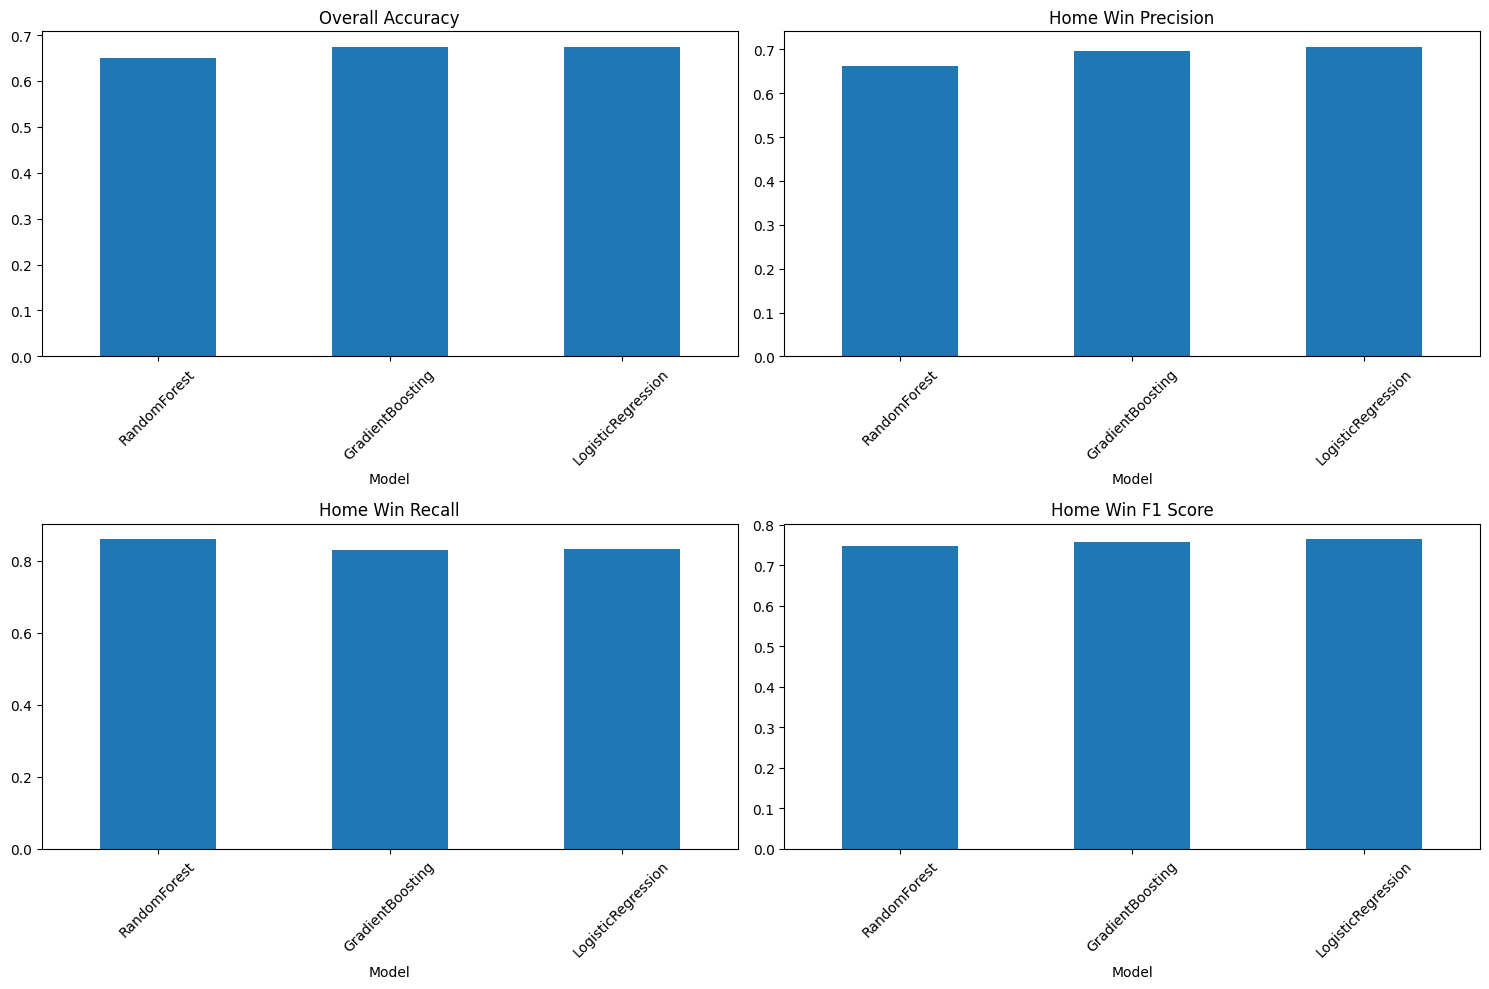

Model Comparison:
                Model  Accuracy  Precision_Home  Precision_Draw  \
0        RandomForest     0.651           0.662           0.479   
1    GradientBoosting     0.673           0.697           0.527   
2  LogisticRegression     0.674           0.706           0.500   

   Precision_Away  Recall_Home  Recall_Draw  Recall_Away  F1_Home  F1_Draw  \
0           0.672        0.860        0.161        0.750    0.748    0.241   
1           0.709        0.831        0.353        0.711    0.758    0.423   
2           0.708        0.833        0.316        0.740    0.764    0.388   

   F1_Away  
0    0.709  
1    0.710  
2    0.723  
Models saved with prefix: football_model_20250908_144702


In [4]:
# 3. Modellépítés - JAVÍTOTT VERZIÓ (végtelen értékek kezelésével)
# Check which features are available
available_features = [
    'Home_Implied_Prob', 'Draw_Implied_Prob', 'Away_Implied_Prob',
    'Home_Points_Last_5', 'Home_Goals_For_Last_5', 'Home_Goals_Against_Last_5',
    'Away_Points_Last_5', 'Away_Goals_For_Last_5', 'Away_Goals_Against_Last_5',
    'Home_Advantage', 'Days_Since_Last_Home_Match', 'Days_Since_Last_Away_Match'
]

# Only use features that actually exist in the dataframe
feature_columns = [col for col in available_features if col in df.columns]

print(f"Using features: {feature_columns}")

# Filter out matches with missing features and target
df_model = df.dropna(subset=feature_columns + ['Target'])

# Data cleaning: remove infinite values and extreme outliers
def clean_dataframe(df, feature_columns):
    df_clean = df.copy()
    
    # Replace infinite values with NaN
    for col in feature_columns:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].replace([np.inf, -np.inf], np.nan)
    
    # Remove rows with any NaN values in features or target
    df_clean = df_clean.dropna(subset=feature_columns + ['Target'])
    
    # Remove extreme outliers (beyond 3 standard deviations)
    for col in feature_columns:
        if df_clean[col].dtype in [np.float64, np.float32]:
            z_scores = np.abs(stats.zscore(df_clean[col]))
            df_clean = df_clean[z_scores < 3]
    
    return df_clean

df_model_clean = clean_dataframe(df_model, feature_columns)

print(f"Original data: {len(df_model)} matches")
print(f"After cleaning: {len(df_model_clean)} matches")

if len(df_model_clean) == 0:
    print("Error: No data available for modeling after cleaning")
else:
    # TimeSeriesSplit setup
    from sklearn.preprocessing import RobustScaler
    from sklearn.model_selection import cross_val_score
    import numpy as np

    # Sort by date for time series split
    df_model_clean = df_model_clean.sort_values('Date')
    X = df_model_clean[feature_columns]
    y = df_model_clean['Target']

    # Create TimeSeriesSplit
    tscv = TimeSeriesSplit(n_splits=5)

    # For final evaluation, use the last split as test set
    splits = list(tscv.split(X))
    train_idx, test_idx = splits[-1]  # Last split for final evaluation

    # Scale features
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X.iloc[train_idx])
    X_test_scaled = scaler.transform(X.iloc[test_idx])

    X_train = pd.DataFrame(X_train_scaled, columns=feature_columns, index=X.iloc[train_idx].index)
    X_test = pd.DataFrame(X_test_scaled, columns=feature_columns, index=X.iloc[test_idx].index)

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    # For backtesting, we'll need the test DataFrame
    test_df = df_model_clean.iloc[test_idx]

    print(f"Train matches: {len(X_train)}, Test matches: {len(X_test)}")
    print(f"TimeSeriesSplit with {tscv.n_splits} folds")

    # Baseline models with simpler parameters
    models = {
        'RandomForest': RandomForestClassifier(
            n_estimators=100, 
            random_state=42, 
            max_depth=5,
            min_samples_split=10,
            min_samples_leaf=5
        ),
        'GradientBoosting': GradientBoostingClassifier(
            n_estimators=100, 
            random_state=42, 
            max_depth=3,
            learning_rate=0.1,
            subsample=0.8
        ),
        'LogisticRegression': None  # Később hozzáadunk egy logisztikus regressziót is
    }

    # Train and validate models with TimeSeriesSplit
    calibrated_models = {}
    cv_scores = {}

    for name, model in models.items():
        try:
            if model is not None:
                print(f"Training {name} with TimeSeriesSplit...")
                
                # Cross-validation scores
                cv_accuracy = cross_val_score(model, X, y, cv=tscv, scoring='accuracy')
                cv_scores[name] = {
                    'accuracy_mean': cv_accuracy.mean(),
                    'accuracy_std': cv_accuracy.std(),
                    'cv_scores': cv_accuracy
                }
                
                print(f"{name} CV Accuracy: {cv_accuracy.mean():.3f} (+/- {cv_accuracy.std() * 2:.3f})")
                
                # Train final model on training data
                model.fit(X_train, y_train)
                
                # Check feature importance for debugging
                if hasattr(model, 'feature_importances_'):
                    importance_df = pd.DataFrame({
                        'feature': feature_columns,
                        'importance': model.feature_importances_
                    }).sort_values('importance', ascending=False)
                    print(f"{name} feature importance:\n{importance_df.head(5)}")
                
                calibrated_models[name] = model
                print(f"{name} trained successfully")
                
        except Exception as e:
            print(f"Error training {name}: {e}")
            import traceback
            traceback.print_exc()

    # Add a simple logistic regression model
    from sklearn.linear_model import LogisticRegression
    
    try:
        logreg = LogisticRegression(
            multi_class='multinomial',
            solver='lbfgs',
            max_iter=1000,
            random_state=42,
            C=0.1
        )
        logreg.fit(X_train, y_train)
        calibrated_models['LogisticRegression'] = logreg
        print("LogisticRegression trained successfully")
    except Exception as e:
        print(f"Error training LogisticRegression: {e}")

    # Add cross-validation scores for LogisticRegression if trained successfully
    if 'LogisticRegression' in calibrated_models:
        try:
            cv_accuracy = cross_val_score(logreg, X, y, cv=tscv, scoring='accuracy')
            cv_scores['LogisticRegression'] = {
                'accuracy_mean': cv_accuracy.mean(),
                'accuracy_std': cv_accuracy.std(),
                'cv_scores': cv_accuracy
            }
            print(f"LogisticRegression CV Accuracy: {cv_accuracy.mean():.3f} (+/- {cv_accuracy.std() * 2:.3f})")
        except Exception as e:
            print(f"Error calculating CV for LogisticRegression: {e}")

    # Display cross-validation results summary
    print("\n" + "="*50)
    print("CROSS-VALIDATION RESULTS SUMMARY")
    print("="*50)
    for name, scores in cv_scores.items():
        print(f"{name:20} | Mean: {scores['accuracy_mean']:.3f} | Std: {scores['accuracy_std']:.3f}")
    
    # Predict probabilities
    predictions = {}
    for name, model in calibrated_models.items():
        try:
            probs = model.predict_proba(X_test)
            predictions[name] = probs
            
            # Calculate accuracy
            preds = model.predict(X_test)
            accuracy = accuracy_score(y_test, preds)
            print(f"{name} predictions made - Accuracy: {accuracy:.3f}")
            
        except Exception as e:
            print(f"Error predicting with {name}: {e}")

    # Add confusion matrix and classification metrics
    from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support
    import matplotlib.pyplot as plt
    import seaborn as sns

    def plot_confusion_matrix(y_true, y_pred, model_name):
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=['Home', 'Draw', 'Away'],
                    yticklabels=['Home', 'Draw', 'Away'])
        plt.title(f'Confusion Matrix - {model_name}')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.show()
        
        # Classification report
        print(f"Classification Report - {model_name}:")
        print(classification_report(y_true, y_pred, 
                                target_names=['Home', 'Draw', 'Away']))

    # For each model, calculate and display metrics
    for name, model in calibrated_models.items():
        try:
            y_pred = model.predict(X_test)
            plot_confusion_matrix(y_test, y_pred, name)
            
            # Additional metrics
            precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
            print(f"{name} - Weighted Precision: {precision:.3f}, Recall: {recall:.3f}, F1: {f1:.3f}")
            
        except Exception as e:
            print(f"Error generating metrics for {name}: {e}")

    def plot_feature_importance(model, feature_names, model_name, top_n=10):
        if hasattr(model, 'feature_importances_'):
            importance = model.feature_importances_
            indices = np.argsort(importance)[::-1]
            
            plt.figure(figsize=(10, 6))
            plt.title(f'Feature Importance - {model_name}')
            plt.bar(range(min(top_n, len(importance))), 
                    importance[indices][:top_n])
            plt.xticks(range(min(top_n, len(importance))), 
                    [feature_names[i] for i in indices[:top_n]], rotation=45)
            plt.tight_layout()
            plt.show()
            
        elif hasattr(model, 'coef_'):
            # For linear models
            coef = model.coef_
            if len(coef.shape) > 1:  # multiclass
                for i in range(coef.shape[0]):
                    importance = np.abs(coef[i])
                    indices = np.argsort(importance)[::-1]
                    
                    plt.figure(figsize=(10, 6))
                    plt.title(f'Feature Importance - {model_name} (Class {i})')
                    plt.bar(range(min(top_n, len(importance))), 
                            importance[indices][:top_n])
                    plt.xticks(range(min(top_n, len(importance))), 
                            [feature_names[i] for i in indices[:top_n]], rotation=45)
                    plt.tight_layout()
                    plt.show()

    # Plot feature importance for each model
    for name, model in calibrated_models.items():
        plot_feature_importance(model, feature_columns, name)

    def analyze_predictions(predictions, actual, model_name):
        plt.figure(figsize=(15, 5))
        
        # Prediction distribution
        plt.subplot(1, 3, 1)
        for i, outcome in enumerate(['Home', 'Draw', 'Away']):
            plt.hist(predictions[:, i], alpha=0.7, label=outcome, bins=30)
        plt.title(f'Prediction Distribution - {model_name}')
        plt.xlabel('Predicted Probability')
        plt.ylabel('Frequency')
        plt.legend()
        
        # Confidence vs accuracy
        plt.subplot(1, 3, 2)
        max_probs = np.max(predictions, axis=1)
        correct = (np.argmax(predictions, axis=1) == actual)
        
        # Bin by confidence
        bins = np.linspace(0.3, 1.0, 10)
        bin_centers = (bins[:-1] + bins[1:]) / 2
        accuracy_per_bin = []
        
        for i in range(len(bins)-1):
            mask = (max_probs >= bins[i]) & (max_probs < bins[i+1])
            if np.sum(mask) > 0:
                accuracy = np.mean(correct[mask])
                accuracy_per_bin.append(accuracy)
            else:
                accuracy_per_bin.append(0)
        
        plt.plot(bin_centers, accuracy_per_bin, 'o-')
        plt.plot([0.3, 1.0], [0.3, 1.0], 'r--', alpha=0.5)
        plt.title('Confidence vs Accuracy')
        plt.xlabel('Prediction Confidence')
        plt.ylabel('Actual Accuracy')
        
        # Calibration curve
        from sklearn.calibration import calibration_curve
        plt.subplot(1, 3, 3)
        
        for i, outcome in enumerate(['Home', 'Draw', 'Away']):
            prob_true, prob_pred = calibration_curve((actual == i), predictions[:, i], n_bins=10)
            plt.plot(prob_pred, prob_true, 'o-', label=outcome)
        
        plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
        plt.title('Calibration Curve')
        plt.xlabel('Mean predicted probability')
        plt.ylabel('Fraction of positives')
        plt.legend()
        
        plt.tight_layout()
        plt.show()

    # Analyze predictions for each model
    for name, probs in predictions.items():
        analyze_predictions(probs, y_test.values, name)

    try:
        import shap
        
        # Initialize JS for visualization
        shap.initjs()
        
        for name, model in calibrated_models.items():
            try:
                # Create explainer
                if hasattr(model, 'predict_proba'):
                    explainer = shap.Explainer(model, X_train)
                    shap_values = explainer(X_test)
                    
                    # Summary plot
                    plt.figure(figsize=(12, 8))
                    shap.summary_plot(shap_values, X_test, feature_names=feature_columns, show=False)
                    plt.title(f'SHAP Summary - {name}')
                    plt.tight_layout()
                    plt.show()
                    
                    # Force plot for a few examples
                    print(f"SHAP Force plots for {name} (first 3 examples):")
                    for i in range(min(3, len(X_test))):
                        shap.force_plot(explainer.expected_value, shap_values[i].values, 
                                    X_test.iloc[i], feature_names=feature_columns, matplotlib=True)
                        plt.title(f'Example {i+1} - True: {y_test.iloc[i]}')
                        plt.show()
                        
            except Exception as e:
                print(f"SHAP error for {name}: {e}")
                
    except ImportError:
        print("SHAP package not installed. Install with: pip install shap")

    def analyze_errors(predictions, actual, features_df, model_name):
        # Create error analysis dataframe
        errors_df = features_df.copy()
        errors_df['Actual'] = actual
        errors_df['Predicted'] = np.argmax(predictions, axis=1)
        errors_df['Confidence'] = np.max(predictions, axis=1)
        errors_df['Correct'] = (errors_df['Actual'] == errors_df['Predicted'])
        errors_df['Error_Type'] = 'Correct'
        errors_df.loc[~errors_df['Correct'], 'Error_Type'] = 'Incorrect'
        
        # Analyze errors by feature ranges
        print(f"Error Analysis - {model_name}:")
        print("=" * 50)
        
        for feature in ['Home_Implied_Prob', 'Away_Implied_Prob', 'Home_Points_Last_5']:
            if feature in errors_df.columns:
                # Bin by feature values
                errors_df[f'{feature}_bin'] = pd.qcut(errors_df[feature], 4)
                error_rate = errors_df.groupby(f'{feature}_bin')['Correct'].mean()
                print(f"Error rate by {feature}:")
                print(error_rate)
                print()
        
        # Most common error patterns
        error_cases = errors_df[~errors_df['Correct']]
        if len(error_cases) > 0:
            print("Most common error patterns:")
            print(error_cases['Actual'].value_counts())
            print("Predicted as:")
            print(error_cases['Predicted'].value_counts())
        
        return errors_df

    # Perform error analysis for each model
    error_dfs = {}
    for name, probs in predictions.items():
        error_dfs[name] = analyze_errors(probs, y_test.values, X_test, name)

    def compare_models(models, X_test, y_test, predictions):
        comparison_results = []
        
        for name, model in models.items():
            if name in predictions:
                y_pred = np.argmax(predictions[name], axis=1)
                accuracy = accuracy_score(y_test, y_pred)
                
                # Calculate precision, recall, f1 for each class
                precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average=None)
                
                comparison_results.append({
                    'Model': name,
                    'Accuracy': accuracy,
                    'Precision_Home': precision[0],
                    'Precision_Draw': precision[1],
                    'Precision_Away': precision[2],
                    'Recall_Home': recall[0],
                    'Recall_Draw': recall[1],
                    'Recall_Away': recall[2],
                    'F1_Home': f1[0],
                    'F1_Draw': f1[1],
                    'F1_Away': f1[2]
                })
        
        comparison_df = pd.DataFrame(comparison_results)
        
        # Plot comparison
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        metrics_to_plot = ['Accuracy', 'Precision_Home', 'Recall_Home', 'F1_Home']
        titles = ['Overall Accuracy', 'Home Win Precision', 'Home Win Recall', 'Home Win F1 Score']
        
        for i, (metric, title) in enumerate(zip(metrics_to_plot, titles)):
            ax = axes[i//2, i%2]
            comparison_df.plot(x='Model', y=metric, kind='bar', ax=ax, legend=False)
            ax.set_title(title)
            ax.tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.show()
        
        return comparison_df

    # Compare all models
    model_comparison = compare_models(calibrated_models, X_test, y_test, predictions)
    print("Model Comparison:")
    print(model_comparison.round(3))

    # Save the scaler and feature columns for later use
    model_artifacts = {
        'scaler': scaler,
        'feature_columns': feature_columns,
        'models': calibrated_models
    }

    # 3.5. Modellek mentése fájlba
    import pickle
    import joblib
    from datetime import datetime

    def save_models(model_artifacts, cv_scores, filename_prefix='football_model'):
        """
        Save models, scaler, feature columns and performance metrics to files
        """
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f"{filename_prefix}_{timestamp}"
        
        # Save model artifacts
        with open(f'models/{filename}_artifacts.pkl', 'wb') as f:
            pickle.dump(model_artifacts, f)
        
        # Save cross-validation scores
        with open(f'models/{filename}_cv_scores.pkl', 'wb') as f:
            pickle.dump(cv_scores, f)
        
        # Save individual models for easier loading
        for model_name, model in model_artifacts['models'].items():
            joblib.dump(model, f'models/{filename}_{model_name}.joblib')
        
        # Save scaler
        joblib.dump(model_artifacts['scaler'], f'models/{filename}_scaler.joblib')
        
        print(f"Models saved with prefix: {filename}")
        return filename

    # Save all models and artifacts
    if 'model_artifacts' in locals() and 'cv_scores' in locals():
        saved_filename = save_models(model_artifacts, cv_scores)
    else:
        print("Models not available for saving")

In [ ]:
# 4. Backtesting és értékelés - BŐVÍTETT VERZIÓ több bet-sizinggel
def calculate_betting_metrics_comprehensive(predictions, actual, odds_df, threshold=0.05):
    """
    Calculate comprehensive betting performance metrics with multiple bet sizing strategies
    """
    results = []
    
    # Bet sizing strategies
    bet_sizing_strategies = {
        'Flat1': lambda odds, prob, bankroll: 10,  # Mindig 10 egység
        'Fixed0.02': lambda odds, prob, bankroll: min(20, bankroll * 0.02),  # Max 20 egység, bankroll 2%
        'Variance': lambda odds, prob, bankroll: min(10, 20 / odds) if odds > 0 else 0,
        'Fractional': lambda odds, prob, bankroll: min(10, 20 / (odds - 1)) if odds > 1 else 0,
        'Kelly': lambda odds, prob, bankroll: min(50, max(0, (prob * odds - 1) / (odds - 1)) * bankroll * 0.0075) if odds > 1 else 0,
        'PropoAJ': lambda odds, prob, bankroll: min(10, bankroll * (prob - 1/odds) / (odds - 1) / 6)
    }
    
    for model_name, probs in predictions.items():
        try:
            # Get available odds columns
            odds_columns = {}
            for outcome in ['H', 'D', 'A']:
                avg_col = f'Avg{outcome}'
                if avg_col in odds_df.columns:
                    odds_columns[outcome] = avg_col
                else:
                    for prefix in ['B365', 'BW', 'IW', 'WH']:
                        col_name = f'{prefix}{outcome}'
                        if col_name in odds_df.columns:
                            odds_columns[outcome] = col_name
                            break
            
            if len(odds_columns) < 3:
                continue
            
            # Clean odds data
            home_odds = np.clip(odds_df[odds_columns['H']].values, 1.01, 1000)
            draw_odds = np.clip(odds_df[odds_columns['D']].values, 1.01, 1000)
            away_odds = np.clip(odds_df[odds_columns['A']].values, 1.01, 1000)
            
            home_implied = 1 / home_odds
            draw_implied = 1 / draw_odds
            away_implied = 1 / away_odds
            
            # Find value bets
            home_value_bets = (probs[:, 0] > home_implied + threshold)
            away_value_bets = (probs[:, 2] > away_implied + threshold)
            draw_value_bets = (probs[:, 1] > draw_implied + threshold)
            
            # Test each bet sizing strategy
            for strategy_name, strategy_func in bet_sizing_strategies.items():
                bankroll = 1000  # Kezdeti bankroll
                bankroll_history = [bankroll]
                bets_placed = 0
                
                home_bets = 0
                away_bets = 0
                draw_bets = 0
                home_wins = 0
                away_wins = 0
                draw_wins = 0
                
                for i in range(len(actual)):
                    bet_amount = 0
                    outcome = None
                    odds = 0
                    predicted_prob = 0
                    
                    # Determine bet type and amount
                    if home_value_bets[i]:
                        bet_amount = strategy_func(home_odds[i], probs[i, 0], bankroll)
                        outcome = 0
                        odds = home_odds[i]
                        predicted_prob = probs[i, 0]
                        home_bets += 1
                        
                    elif away_value_bets[i]:
                        bet_amount = strategy_func(away_odds[i], probs[i, 2], bankroll)
                        outcome = 2
                        odds = away_odds[i]
                        predicted_prob = probs[i, 2]
                        away_bets += 1
                        
                    elif draw_value_bets[i]:
                        bet_amount = strategy_func(draw_odds[i], probs[i, 1], bankroll)
                        outcome = 1
                        odds = draw_odds[i]
                        predicted_prob = probs[i, 1]
                        draw_bets += 1
                    
                    # Place bet if amount is positive and reasonable
                    if bet_amount > 0 and bankroll >= bet_amount and bet_amount <= bankroll * 0.1:  # Max 10% of bankroll per bet
                        bets_placed += 1
                        
                        if actual[i] == outcome:
                            # Win bet
                            profit = bet_amount * (odds - 1)
                            bankroll += profit
                            if outcome == 0:
                                home_wins += 1
                            elif outcome == 2:
                                away_wins += 1
                            else:
                                draw_wins += 1
                        else:
                            # Lose bet
                            bankroll -= bet_amount

                    # Bankroll protection - stop if too low
                    if bankroll < 50:  # Stop if bankroll drops below 50
                        break
                    
                    bankroll_history.append(bankroll)
                
                if bets_placed > 0:
                    total_bets = home_bets + away_bets + draw_bets
                    total_wins = home_wins + away_wins + draw_wins
                    hit_rate = total_wins / total_bets if total_bets > 0 else 0
                    
                    # Calculate returns from bankroll history
                    returns = np.diff(bankroll_history)
                    total_return = bankroll_history[-1] - 1000
                    roi = total_return / sum([abs(r) for r in returns if r < 0]) if any(r < 0 for r in returns) else 0
                    
                    # Drawdown calculation
                    equity_curve = np.array(bankroll_history[1:])  # Skip initial 1000
                    peak = np.maximum.accumulate(equity_curve)
                    drawdown = (peak - equity_curve) / peak
                    max_drawdown = np.max(drawdown) if len(drawdown) > 0 else 0
                    
                    # Sharpe ratio
                    daily_returns = returns / np.array(bankroll_history[:-1])
                    sharpe_ratio = np.mean(daily_returns) / np.std(daily_returns) * np.sqrt(365) if len(daily_returns) > 1 and np.std(daily_returns) > 0 else 0
                    
                    # Profit factor
                    total_profit = returns[returns > 0].sum()
                    total_loss = abs(returns[returns < 0].sum())
                    profit_factor = total_profit / total_loss if total_loss > 0 else float('inf')
                    
                    # Average bet size
                    avg_bet_size = np.mean([abs(r) for r in returns if r != 0]) if any(r != 0 for r in returns) else 0
                    avg_return = total_return / len(bankroll_history)
                    reward_risk_ratio = avg_return / avg_bet_size

                    results.append({
                        'Model_Strategy': f"{model_name}_{strategy_name}",
                        'Model': model_name,
                        'Strategy': strategy_name,
                        'Final_Bankroll': bankroll_history[-1],
                        'Total_Return': total_return,
                        'ROI': roi,
                        'Hit_Rate': hit_rate,
                        'Max_Drawdown': max_drawdown,
                        'Sharpe_Ratio': sharpe_ratio,
                        'Profit_Factor': profit_factor,
                        'Total_Bets': total_bets,
                        'Home_Bets': home_bets,
                        'Away_Bets': away_bets,
                        'Draw_Bets': draw_bets,
                        'Home_Wins': home_wins,
                        'Away_Wins': away_wins,
                        'Draw_Wins': draw_wins,
                        'Avg_Bet_Size': avg_bet_size,
                        'Avg_Return': avg_return,
                        'Reward/Risk': reward_risk_ratio,
                        'Bankroll_History': bankroll_history
                    })
                
        except Exception as e:
            print(f"Error in {model_name}_{strategy_name}: {e}")
            continue
    
    return pd.DataFrame(results)

# Calculate comprehensive metrics
if 'predictions' in locals() and predictions:
    # Get odds data
    odds_columns = [col for col in test_df.columns if any(x in col for x in ['Avg', 'B365', 'BW', 'IW', 'WH']) and col[-1] in ['H', 'D', 'A']]
    odds_test = test_df[odds_columns].copy()
    odds_test = odds_test.replace(0, np.nan)
    odds_test = odds_test.fillna(odds_test.mean())
    
    # Calculate metrics with multiple strategies
    metrics_df = calculate_betting_metrics_comprehensive(predictions, y_test.values, odds_test)
    
    if not metrics_df.empty:
        print("\n" + "="*80)
        print("COMPREHENSIVE BETTING PERFORMANCE METRICS")
        print("="*80)
        
        # Display results in a nice table
        display_columns = [
            'Model_Strategy', 'Final_Bankroll', 'Total_Return', 'ROI', 
            'Hit_Rate', 'Max_Drawdown', 'Sharpe_Ratio', 'Profit_Factor',
            'Total_Bets', 'Avg_Bet_Size', 'Avg_Return', 'Reward/Risk'
        ]
        
        # Format the display
        display_df = metrics_df[display_columns].copy()
        display_df['Final_Bankroll'] = display_df['Final_Bankroll'].round(0)
        display_df['Total_Return'] = display_df['Total_Return'].round(0)
        display_df['ROI'] = display_df['ROI'].apply(lambda x: f"{x:.2%}")
        display_df['Hit_Rate'] = display_df['Hit_Rate'].apply(lambda x: f"{x:.2%}")
        display_df['Max_Drawdown'] = display_df['Max_Drawdown'].apply(lambda x: f"{x:.2%}")
        display_df['Sharpe_Ratio'] = display_df['Sharpe_Ratio'].round(3)
        display_df['Profit_Factor'] = display_df['Profit_Factor'].round(2)
        display_df['Avg_Bet_Size'] = display_df['Avg_Bet_Size'].round(2)
        display_df['Avg_Return'] = display_df['Avg_Return'].round(2)
        display_df['Reward/Risk'] = display_df['Reward/Risk'].round(3)
        
        from IPython.display import display
        display(display_df.sort_values('Total_Return', ascending=False))
        
        # Plot bankroll history for top 5 strategies
        plt.figure(figsize=(15, 10))
        
        # Top 5 by total return
        top_strategies = metrics_df.nlargest(5, 'Total_Return')
        
        for _, row in top_strategies.iterrows():
            plt.plot(row['Bankroll_History'], 
                    label=f"{row['Model_Strategy']} (Final: €{row['Final_Bankroll']:.0f})", 
                    linewidth=2)
        
        plt.title('Bankroll History - Top 5 Strategies', fontsize=16)
        plt.xlabel('Bet Number', fontsize=12)
        plt.ylabel('Bankroll (€)', fontsize=12)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.axhline(y=1000, color='red', linestyle='--', alpha=0.5, label='Starting Bankroll')
        plt.tight_layout()
        plt.show()
        
        # Additional detailed analysis
        print("\n" + "="*60)
        print("DETAILED ANALYSIS BY STRATEGY TYPE")
        print("="*60)
        
        # Group by strategy type
        strategy_stats = metrics_df.groupby('Strategy').agg({
            'Total_Return': 'mean',
            'ROI': 'mean',
            'Hit_Rate': 'mean',
            'Max_Drawdown': 'mean',
            'Profit_Factor': 'mean'
        }).round(4)
        
        strategy_stats['ROI'] = strategy_stats['ROI'].apply(lambda x: f"{x:.2%}")
        strategy_stats['Hit_Rate'] = strategy_stats['Hit_Rate'].apply(lambda x: f"{x:.2%}")
        strategy_stats['Max_Drawdown'] = strategy_stats['Max_Drawdown'].apply(lambda x: f"{x:.2%}")
        
        display(strategy_stats.sort_values('Total_Return', ascending=False))
        
        # Best overall strategy
        best_strategy = metrics_df.loc[metrics_df['Total_Return'].idxmax()]
        print(f"\nBEST OVERALL STRATEGY: {best_strategy['Model_Strategy']}")
        print(f"Final Bankroll: €{best_strategy['Final_Bankroll']:.2f}")
        print(f"Total Return: €{best_strategy['Total_Return']:.2f}")
        print(f"ROI: {best_strategy['ROI']:.2%}")
        print(f"Hit Rate: {best_strategy['Hit_Rate']:.2%}")
        
    else:
        print("No metrics calculated - check if any value bets were found")
else:
    print("No predictions available for backtesting")